<a href="https://colab.research.google.com/github/Roshniazath006/roshni/blob/main/Copy_of_Untitled53.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_excel("Employee.xlsx")

print("DATASET LOADED SUCCESSFULLY")
print(df.head())

DATASET LOADED SUCCESSFULLY
   Employee_ID        Department  Gender  Age   Job_Title        Hire_Date  \
0            1                IT    Male   55  Specialist  00:03:05.600000   
1            2           Finance    Male   29   Developer  00:03:05.600000   
2            3           Finance    Male   55  Specialist  00:03:05.600000   
3            4  Customer Support  Female   48     Analyst  00:03:05.600000   
4            5       Engineering  Female   36     Analyst  00:03:05.600000   

   Years_At_Company Education_Level  Unnamed: 8  Monthly_Salary  \
0                 2     High School         NaN            6750   
1                 0     High School         NaN            7500   
2                 8     High School         NaN            5850   
3                 7        Bachelor         NaN            4800   
4                 3        Bachelor         NaN            4800   

   Work_Hours_Per_Week  Projects_Handled  Overtime_Hours  Sick_Days  \
0                   33       

In [ ]:
df.drop(columns=['Unnamed: 8'], inplace=True, errors='ignore')

In [ ]:
df['Performance_Category'] = np.where(
    df['Performance_Score'] >= 4,
    'Best Performer',
    'Worst Performer'
)

In [ ]:
print("\nDATASET INFORMATION")
print(df.info())


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  object 
 5   Hire_Date                    100000 non-null  object 
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  object 
 8   Monthly_Salary               100000 non-null  int64  
 9   Work_Hours_Per_Week          100000 non-null  int64  
 10  Projects_Handled             100000 non-null  int64  
 11  Overtime_Hours               100000 non-null  int64  
 12  Sick_Days                    100000 no

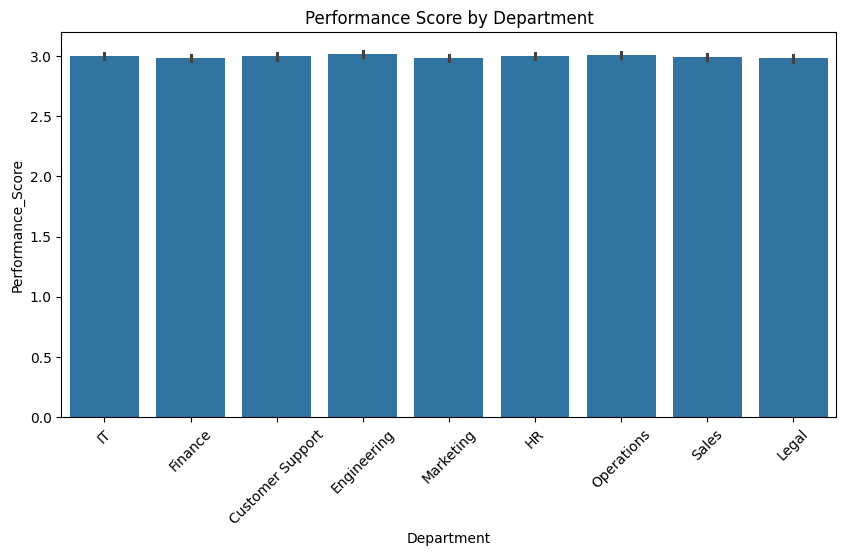

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df,
    x='Department',
    y='Performance_Score'
)

plt.title("Performance Score by Department")
plt.xticks(rotation=45)
plt.show()


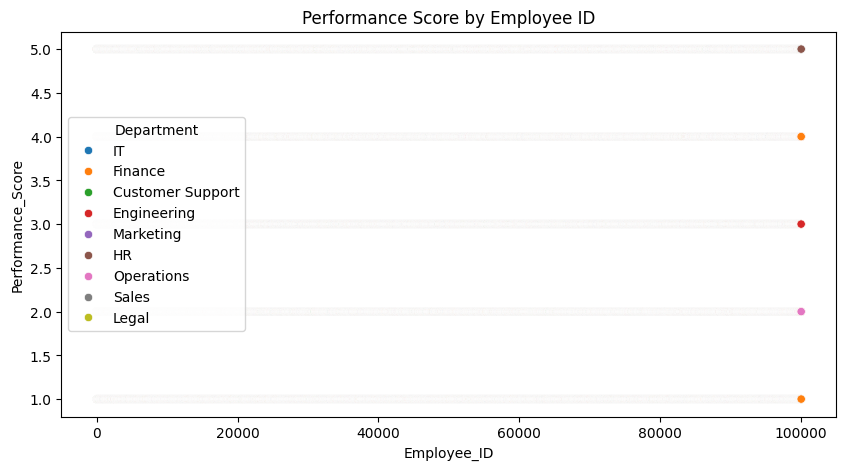

In [ ]:
# ==================================================
# PLOT 2
# PERFORMANCE SCORE BY EMPLOYEE ID
# ==================================================

plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x='Employee_ID',
    y='Performance_Score',
    hue='Department'
)

plt.title("Performance Score by Employee ID")
plt.show()

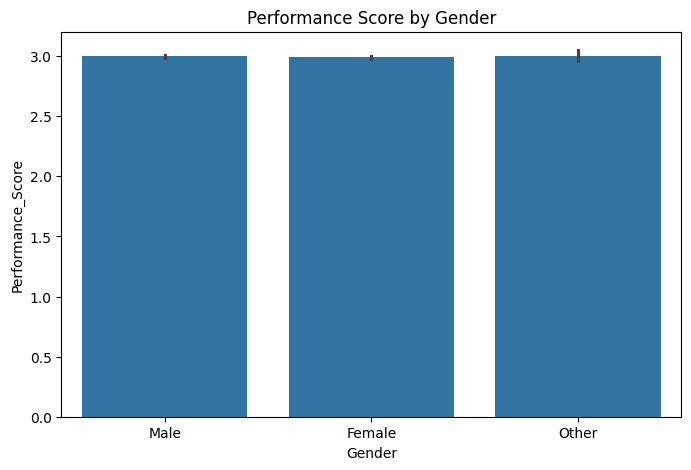

In [ ]:
# ==================================================
# PLOT 3
# PERFORMANCE SCORE BY GENDER
# ==================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Gender',
    y='Performance_Score'
)

plt.title("Performance Score by Gender")
plt.show()

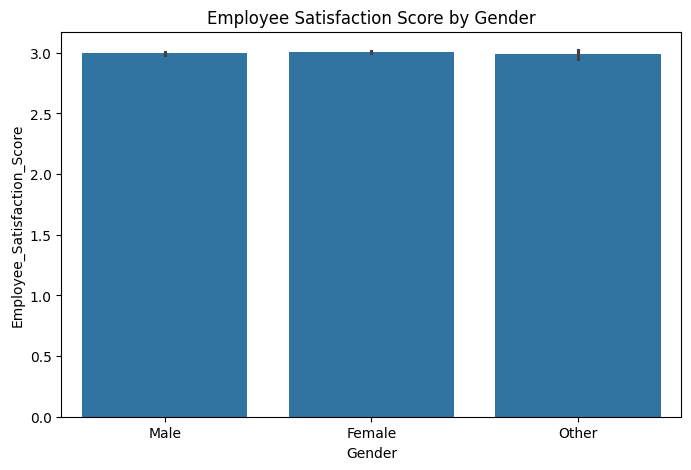

In [ ]:
# ==================================================
# PLOT 4
# SATISFACTION SCORE BY GENDER
# ==================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Gender',
    y='Employee_Satisfaction_Score'
)

plt.title("Employee Satisfaction Score by Gender")
plt.show()


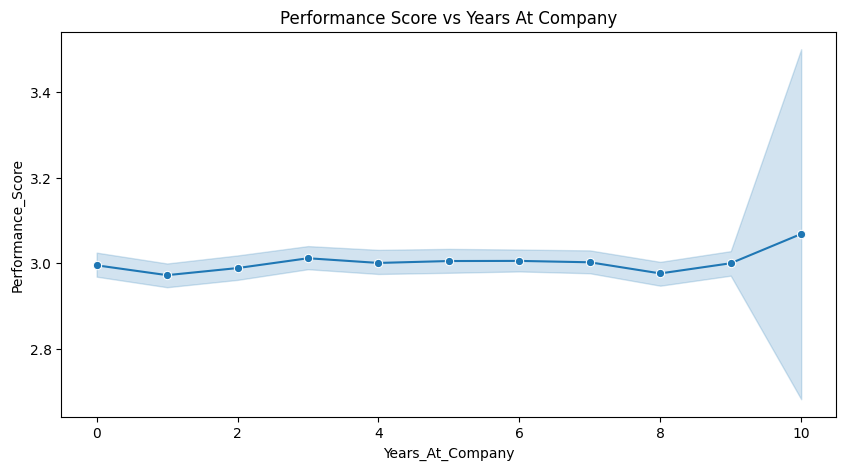

In [ ]:
# ==================================================
# PLOT 5
# PERFORMANCE SCORE VS YEARS AT COMPANY
# ==================================================

plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x='Years_At_Company',
    y='Performance_Score',
    marker='o'
)

plt.title("Performance Score vs Years At Company")
plt.show()

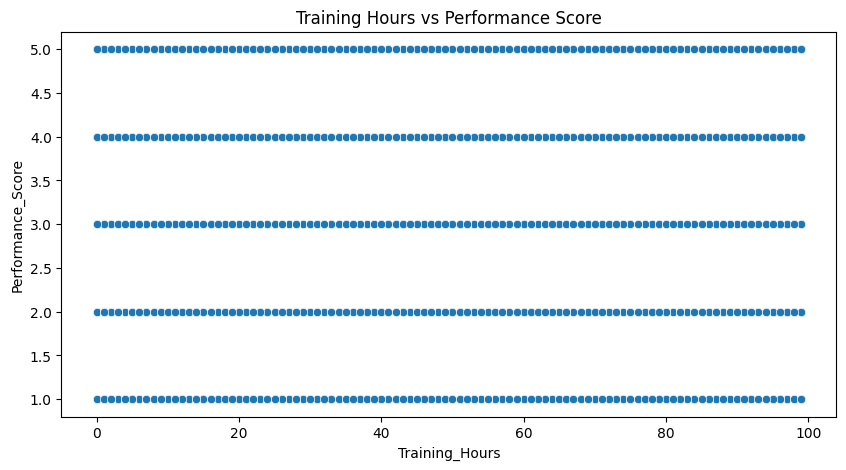

In [ ]:
# ==================================================
# PLOT 6
# TRAINING HOURS VS PERFORMANCE SCORE
# ==================================================

plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x='Training_Hours',
    y='Performance_Score'
)

plt.title("Training Hours vs Performance Score")
plt.show()

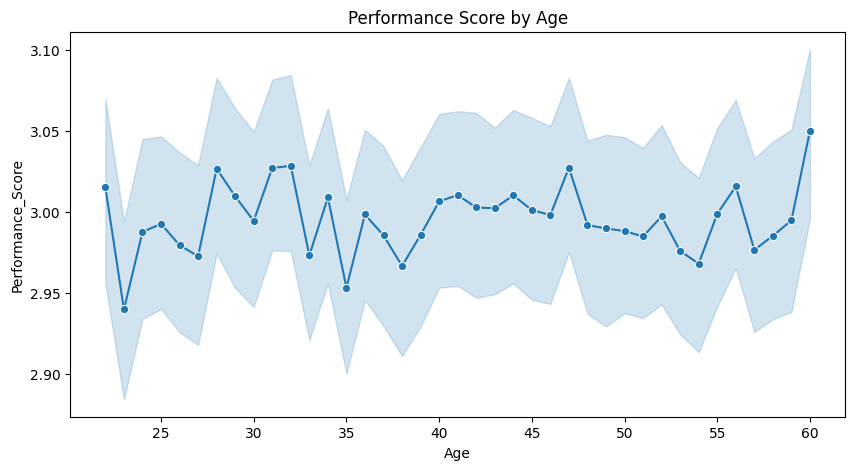

In [ ]:
# ==================================================
# PLOT 7
# PERFORMANCE SCORE BY AGE
# ==================================================

plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x='Age',
    y='Performance_Score',
    marker='o'
)

plt.title("Performance Score by Age")
plt.show()

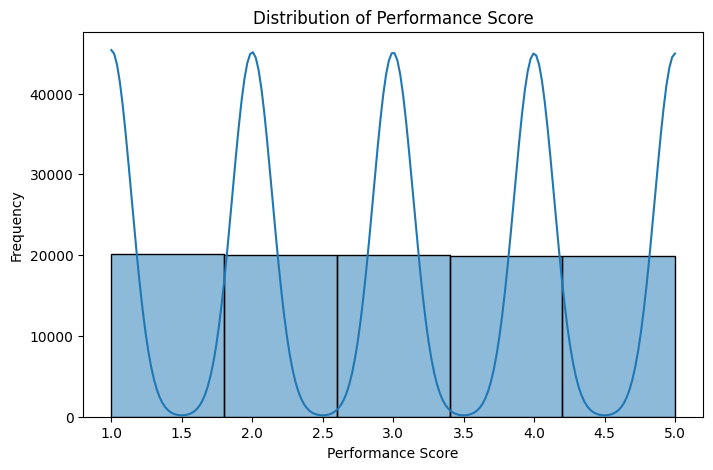

In [ ]:
# ==================================================
# PLOT 8
# DISTRIBUTION OF PERFORMANCE SCORE
# ==================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['Performance_Score'],
    bins=5,
    kde=True
)

plt.title("Distribution of Performance Score")
plt.xlabel("Performance Score")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# ==================================================
# MACHINE LEARNING
# LINEAR REGRESSION
# ==================================================

df_ml = df.copy()

In [ ]:
# Remove columns not useful

df_ml.drop(
    columns=[
        'Hire_Date',
        'Performance_Category'
    ],
    inplace=True,
    errors='ignore'
)

In [ ]:
# Encode text columns

le = LabelEncoder()

for col in df_ml.columns:
    if df_ml[col].dtype == 'object':
        df_ml[col] = le.fit_transform(df_ml[col])

In [ ]:
# Features and Target

X = df_ml.drop('Performance_Score', axis=1)
y = df_ml['Performance_Score']


In [ ]:
# Train Test Split

xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Model Training

model = LinearRegression()

model.fit(xtrain, ytrain)

LinearRegression()

In [ ]:
# Prediction

ypred = model.predict(xtest)

print("\nPREDICTED PERFORMANCE SCORES")
print(ypred)

# Accuracy

print("\nR2 SCORE")
print(r2_score(ytest, ypred))

print("\nMEAN SQUARED ERROR")
print(mean_squared_error(ytest, ypred))



PREDICTED PERFORMANCE SCORES
[3.50860274 4.07558026 3.81768165 ... 3.44518995 4.394832   2.18571825]

R2 SCORE
0.27471813482218455

MEAN SQUARED ERROR
1.4541763303148072


In [ ]:
# Predict Entire Dataset

df['Predicted_Performance'] = model.predict(X)

# Best Employee

best_employee = df.loc[
    df['Predicted_Performance'].idxmax()
]

# Worst Employee

worst_employee = df.loc[
    df['Predicted_Performance'].idxmin()
]

print("\nBEST EMPLOYEE")
print(best_employee)

print("\nWORST EMPLOYEE")
print(worst_employee)



BEST EMPLOYEE
Employee_ID                              46308
Department                         Engineering
Gender                                   Other
Age                                         50
Job_Title                              Manager
Hire_Date                      00:03:05.600000
Years_At_Company                             7
Education_Level                       Bachelor
Monthly_Salary                            9000
Work_Hours_Per_Week                         30
Projects_Handled                            24
Overtime_Hours                               4
Sick_Days                                    6
Remote_Work_Frequency                      100
Team_Size                                    2
Training_Hours                              82
Promotions                                   0
Employee_Satisfaction_Score               4.71
Performance_Score                            5
Performance_Category            Best Performer
Predicted_Performance                 4.51960

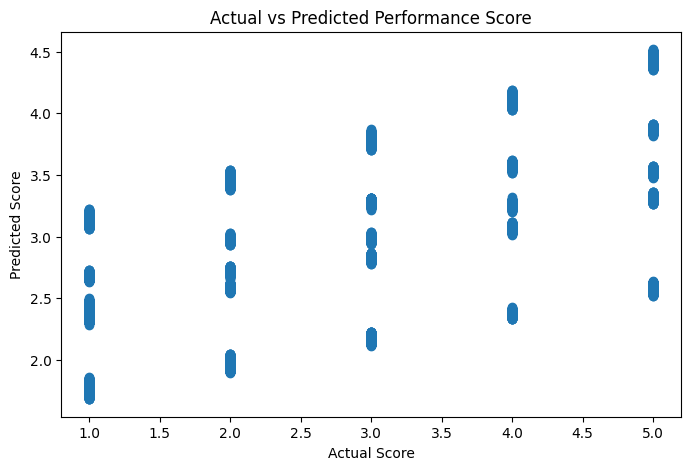

In [ ]:
# ==================================================
# ACTUAL VS PREDICTED
# ==================================================

plt.figure(figsize=(8,5))

plt.scatter(
    ytest,
    ypred
)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Performance Score")

plt.show()